In [156]:
#General
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
plt.style.use('fivethirtyeight')

#Network
import networkx as nx 
import matplotlib.pyplot as plt 
import pylab as plt 
from itertools import count 
from operator import itemgetter 
from networkx.drawing.nx_agraph import graphviz_layout 
import pylab
import random
##These can be installed into your evironments using 
## pip install -r requirements.txt

In [163]:
start = 6500 
end = start + 900
df = pd.read_csv("data/member-edges.csv")
print(len(df))
df = df[start:end]

1176368


c:\PersonalProjects\NetworkAnalysis\social\Lib\site-packages\networkx\drawing\nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
C:\Users\vidha\AppData\Local\Temp\ipykernel_1756\2966366910.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


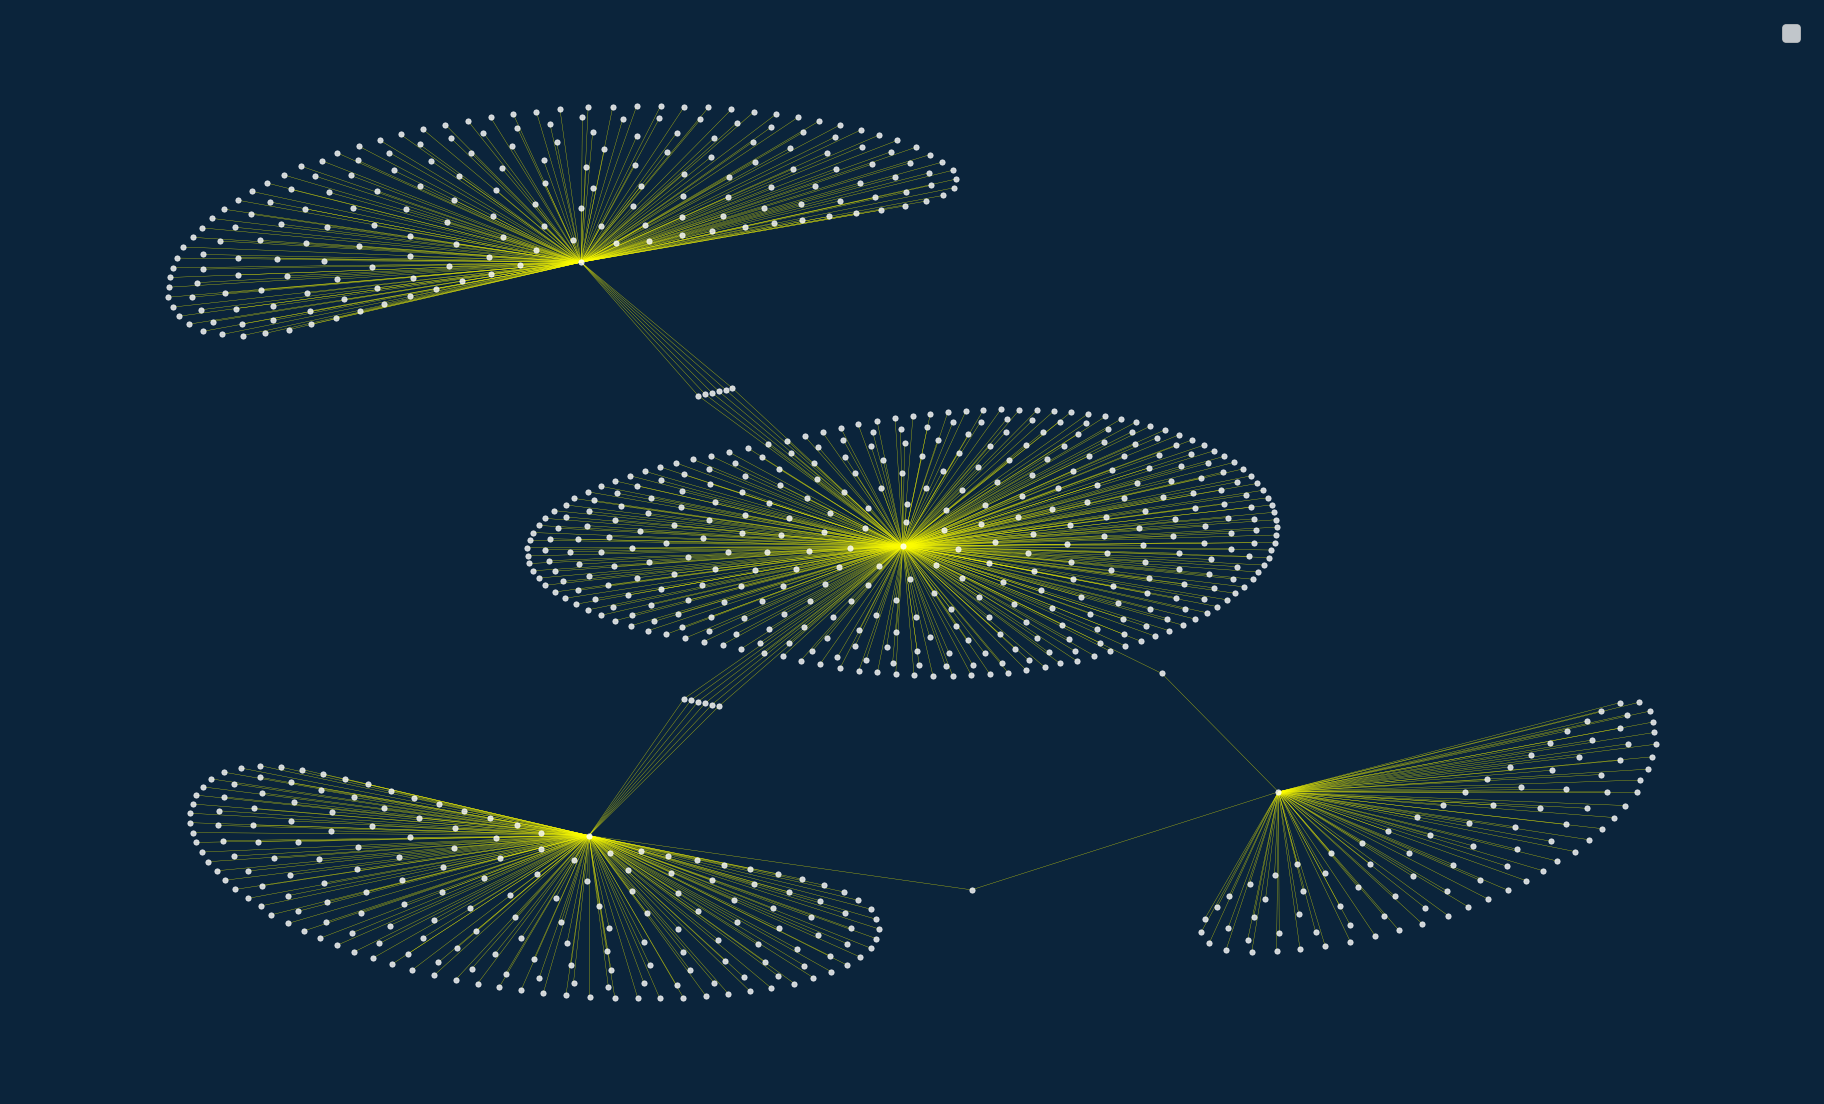

In [ ]:
pd.set_option('display.precision',10)
G = nx.from_pandas_edgelist(df,'member1','member2',create_using=nx.Graph())

nodes = G.nodes()
degree = G.degree()
colors = [degree[n] for n in nodes]
# size = [(degree[n]*5) for n in nodes]
size=10

# pos = nx.kamada_kawai_layout(G)
pos_init = nx.spring_layout(G, k=0.1, iterations=30)
pos = nx.kamada_kawai_layout(G, pos=pos_init)
# # pos = nx.spring_layout(G, k = 0.2)
cmap = plt.cm.viridis_r
# cmap = plt.cm.Greys

vmin = min(colors)
vmax = max(colors)

fig = plt.figure(figsize = (15,9), dpi=120)

nx.draw(G,pos, node_size=size, alpha = 0.8, nodelist = nodes, node_color = 'w', with_labels= False,font_size = 6, width = 0.2, cmap = cmap, edge_color ='yellow')
fig.set_facecolor('#0B243B')

plt.legend()
plt.show()

In [185]:
for i in sorted(G.nodes()):
    G.nodes[i]['Degree'] = G.degree(i)


#extraction of network nodes in a dataframe
nodes_data = pd.DataFrame([i[1] for i in G.nodes(data=True)], index=[i[0] for i in G.nodes(data=True)])
nodes_data = nodes_data.sort_values(by='Degree',ascending= False)
nodes_data.index.names=['ID']
nodes_data.reset_index(level=0, inplace=True)

print(nodes_data.head())

          ID  Degree
0  209453152     398
1  195657825     207
2  228655199     198
3  213745765      97
4  205233254       2


In [226]:
nodes_data['ID'].to_csv("nodes.csv", index=False)
print("Nodes exported to nodes.csv")

# --- Export edges ---
edges_data = pd.DataFrame(list(G.edges()), columns=["member1", "member2"])
edges_data.to_csv("edges.csv", index=False)
print("Edges exported to edges.csv")

Nodes exported to nodes.csv
Edges exported to edges.csv


Initial infected nodes: [230837722, 83381502, 128674982, 204655705, 10055195]


In [148]:
# Betweenness centrality 
bet_cen = nx.betweenness_centrality(G)
df_bet_cen = pd.DataFrame.from_dict(bet_cen, orient='index')
df_bet_cen.columns = ['betweenness_centrality']
df_bet_cen.index.names = ['ID']
df_bet_cen.reset_index(level=0, inplace=True)
analyse= pd.merge(nodes_data,df_bet_cen, on = ['ID'])

# Clustering coefficient 
clust_coefficients = nx.clustering(G)
df_clust = pd.DataFrame.from_dict(clust_coefficients, orient='index')
df_clust.columns = ['clust_coefficient']
df_clust.index.names = ['ID']
df_clust.reset_index(level=0, inplace=True)
analyse= pd.merge(analyse, df_clust, on = ['ID'])

# Closeness centrality 
clo_cen = nx.closeness_centrality(G)
df_clo = pd.DataFrame.from_dict(clo_cen, orient='index')
df_clo.columns = ['closeness_centrality']
df_clo.index.names = ['ID']
df_clo.reset_index(level=0, inplace=True)
analyse= pd.merge(analyse, df_clo, on = ['ID'])

# Eigenvector centrality
eig_cen = nx.eigenvector_centrality(G,max_iter=500, tol=1e-06)
#eig_cen = nx.katz_centrality(G)
# eig_cen = nx.eigenvector_centrality_numpy(G)
df_eig = pd.DataFrame.from_dict(eig_cen, orient='index')
df_eig.columns = ['eigenvector_centrality']
df_eig.index.names = ['ID']
df_eig.reset_index(level=0, inplace=True)
analyse= pd.merge(analyse, df_eig, on = ['ID'])

print(analyse)

            ID  Degree  betweenness_centrality  clust_coefficient  \
0    209453152     398            0.8360481243                  0   
1    195657825     207            0.4012897881                  0   
2    228655199     198            0.3857802644                  0   
3    213745765      97            0.2026983596                  0   
4    205233254       2            0.0581700936                  0   
..         ...     ...                     ...                ...   
885  128294312       1            0.0000000000                  0   
886  182121902       1            0.0000000000                  0   
887   87567792       1            0.0000000000                  0   
888  210754994       1            0.0000000000                  0   
889  213405039       1            0.0000000000                  0   

     closeness_centrality  eigenvector_centrality  
0            0.4759100642            0.7064198679  
1            0.3143564356            0.0221481442  
2            0.

In [ ]:
deg_cen = nx.degree_centrality(G)
df_deg = pd.DataFrame.from_dict(deg_cen, orient='index', columns=['degree_centrality'])

# Closeness centrality
clo_cen = nx.closeness_centrality(G)
df_clo = pd.DataFrame.from_dict(clo_cen, orient='index', columns=['closeness_centrality'])

# Betweenness centrality (shortest-path)
bet_cen = nx.betweenness_centrality(G)
df_bet = pd.DataFrame.from_dict(bet_cen, orient='index', columns=['betweenness_centrality'])

# Current flow closeness centrality
try:
    cf_clo = nx.current_flow_closeness_centrality(G)
    df_cf_clo = pd.DataFrame.from_dict(cf_clo, orient='index', columns=['current_flow_closeness'])
except nx.NetworkXError:
    df_cf_clo = pd.DataFrame(columns=['current_flow_closeness'])  # requires connected graph

# Current flow betweenness centrality
try:
    cf_bet = nx.current_flow_betweenness_centrality(G)
    df_cf_bet = pd.DataFrame.from_dict(cf_bet, orient='index', columns=['current_flow_betweenness'])
except nx.NetworkXError:
    df_cf_bet = pd.DataFrame(columns=['current_flow_betweenness'])

# Eigenvector centrality
eig_cen = nx.eigenvector_centrality(G, max_iter=500, tol=1e-06)
df_eig = pd.DataFrame.from_dict(eig_cen, orient='index', columns=['eigenvector_centrality'])

# Load centrality
load_cen = nx.load_centrality(G)
df_load = pd.DataFrame.from_dict(load_cen, orient='index', columns=['load_centrality'])

# Subgraph centrality
sub_cen = nx.subgraph_centrality(G)
df_sub = pd.DataFrame.from_dict(sub_cen, orient='index', columns=['subgraph_centrality'])

# Harmonic centrality
harm_cen = nx.harmonic_centrality(G)
df_harm = pd.DataFrame.from_dict(harm_cen, orient='index', columns=['harmonic_centrality'])

# Communicability betweenness centrality
try:
    comm_bet = nx.communicability_betweenness_centrality(G)
    df_comm = pd.DataFrame.from_dict(comm_bet, orient='index', columns=['communicability_betweenness'])
except Exception:
    df_comm = pd.DataFrame(columns=['communicability_betweenness'])

# Laplacian centrality (manual implementation)
# (NetworkX doesn’t have this directly, we implement a simple version)
def laplacian_centrality(G):
    L = nx.laplacian_matrix(G).todense()
    energy = sum(sum(abs(val) for val in row) for row in L)
    centrality = {}
    for n in G.nodes():
        G_removed = G.copy()
        G_removed.remove_node(n)
        L_removed = nx.laplacian_matrix(G_removed).todense()
        energy_removed = sum(sum(abs(val) for val in row) for row in L_removed)
        centrality[n] = (energy - energy_removed) / energy
    return centrality

lap_cen = laplacian_centrality(G)
df_lap = pd.DataFrame.from_dict(lap_cen, orient='index', columns=['laplacian_centrality'])

# -----------------------
# Merge all into one DataFrame
dfs = [df_deg, df_clo, df_bet, df_cf_clo, df_cf_bet, df_eig, df_load, 
       df_sub, df_harm, df_comm, df_lap]

analyse = pd.concat(dfs, axis=1)
analyse.index.name = 'ID'
analyse.reset_index(inplace=True)

print(analyse.head())

          ID  degree_centrality  closeness_centrality  betweenness_centrality  \
0  195657825       0.2328458943          0.3143564356            0.4012897881   
1   14670871       0.0011248594          0.2392357374            0.0000000000   
2   81247262       0.0022497188          0.3779761905            0.0581700936   
3  225795116       0.0011248594          0.2392357374            0.0000000000   
4  194923584       0.0011248594          0.2392357374            0.0000000000   

   current_flow_closeness  current_flow_betweenness  eigenvector_centrality  \
0            0.0007871235          4.0560934951e-01            0.0221481442   
1            0.0004632957          1.2816972909e-16            0.0011097278   
2            0.0006409098          5.9103253985e-02            0.0365047355   
3            0.0004632957          0.0000000000e+00            0.0011097278   
4            0.0004632957          0.0000000000e+00            0.0011097278   

   load_centrality  subgraph_centralit

In [151]:
print(analyse.tail())

            ID  degree_centrality  closeness_centrality  \
885  128294312       0.0011248594          0.2363104732   
886  182121902       0.0011248594          0.2363104732   
887   87567792       0.0011248594          0.2363104732   
888  210754994       0.0011248594          0.2363104732   
889  224243134       0.0011248594          0.2363104732   

     betweenness_centrality  current_flow_closeness  current_flow_betweenness  \
885                     0.0            0.0003720469         -2.2501708056e-21   
886                     0.0            0.0003720469         -2.2501708056e-21   
887                     0.0            0.0003720469         -1.1250854028e-21   
888                     0.0            0.0003720469         -5.6254270140e-22   
889                     0.0            0.0003720469          1.1981709506e-16   

     eigenvector_centrality  load_centrality  subgraph_centrality  \
885            0.0001209654              0.0       105.6564317532   
886            0.000

In [152]:
# Save to CSV
analyse.to_csv("graph_centralities.csv", index=False)

# Percolative Centrality 

In [ ]:


n_infected = 10     # number of initial infected
top_k = 100        # among top_k highest degree nodes

# take top_k nodes by degree
top_nodes = nodes_data.head(top_k)["ID"].tolist()

# randomly sample n_infected from them
initial_infected = random.sample(top_nodes, n_infected)

print("Initial infected nodes:", initial_infected)

Initial infected nodes: [5655924, 209775846, 197901531, 209453152, 232746220, 10026392, 228655199, 138382742, 12258718, 228625838]


In [210]:
# parameters
timesteps = 50
p_infect = 0.05   # infection probability
boost_factor = 3.0   # infection more likely if in top-k PC nodes
top_k = 50

# store results
history = []

# state dictionary: 0 = healthy, 1 = infected
state = {n: 0 for n in G.nodes()}
for n in initial_infected:
    state[n] = 1

for t in range(timesteps):
    
    nx.set_node_attributes(G, state, 'infected')  # 0 or 1
    pc = nx.percolation_centrality(G, attribute='infected')
    healthy_nodes = [n for n in G.nodes() if state[n] == 0]
    # sort healthy nodes by percolation centrality and pick top_k
    risky_nodes = set(sorted(healthy_nodes, key=lambda n: pc[n], reverse=True)[:top_k])
    
    new_state = state.copy()
    for node in G.nodes():
        if state[node] == 1:  # if infected
            for neigh in G.neighbors(node):
                prob = p_infect * (boost_factor if neigh in risky_nodes else 1.0)
                if random.random() < prob:
                    new_state[neigh] = 1
    state = new_state.copy()
    infected_count = sum(state.values())
    print("T: ", 890, " H: ", len(healthy_nodes), " R: ", len(risky_nodes), " I: ", infected_count)

    # store full node states for this timestep
    for node, status in state.items():
        history.append({
            "timestep": t,
            "node": node,
            "infected": status,        # 0 = healthy, 1 = infected
            "risky": 1 if node in risky_nodes else 0
        })

# put into dataframe
df_history = pd.DataFrame(history)

# save to CSV
df_history.to_csv("infection_history.csv", index=False)

print(df_history.tail())



T:  890  H:  880  R:  50  I:  28
T:  890  H:  862  R:  50  I:  67
T:  890  H:  823  R:  50  I:  95
T:  890  H:  795  R:  50  I:  136
T:  890  H:  754  R:  50  I:  175
T:  890  H:  715  R:  50  I:  217
T:  890  H:  673  R:  50  I:  256
T:  890  H:  634  R:  50  I:  296
T:  890  H:  594  R:  50  I:  324
T:  890  H:  566  R:  50  I:  353
T:  890  H:  537  R:  50  I:  395
T:  890  H:  495  R:  50  I:  419
T:  890  H:  471  R:  50  I:  445
T:  890  H:  445  R:  50  I:  474
T:  890  H:  416  R:  50  I:  498
T:  890  H:  392  R:  50  I:  521
T:  890  H:  369  R:  50  I:  539
T:  890  H:  351  R:  50  I:  561
T:  890  H:  329  R:  50  I:  584
T:  890  H:  306  R:  50  I:  609
T:  890  H:  281  R:  50  I:  626
T:  890  H:  264  R:  50  I:  644
T:  890  H:  246  R:  50  I:  656
T:  890  H:  234  R:  50  I:  674
T:  890  H:  216  R:  50  I:  692
T:  890  H:  198  R:  50  I:  718
T:  890  H:  172  R:  50  I:  728
T:  890  H:  162  R:  50  I:  738
T:  890  H:  152  R:  50  I:  749
T:  890  H:  141 

In [209]:
print(df_history.head(20))
infected_count = sum(state.values())
print(infected_count)

    timestep       node  infected  risky
0          0  195657825         0      1
1          0   14670871         0      1
2          0   81247262         0      1
3          0  225795116         0      1
4          0  194923584         0      1
5          0  193256517         0      1
6          0  182873170         0      1
7          0   22535251         0      1
8          0  198233173         0      1
9          0  204655705         0      1
10         0  205233254         0      1
11         0  228998249         0      1
12         0   14486634         0      1
13         0  104160362         0      1
14         0  231320697         0      1
15         0  134601852         0      1
16         0  206261374         0      1
17         0  208813186         0      1
18         0  220028036         0      1
19         0  146791582         0      1
882


# VoteRank Centrality

In [225]:
# parameters
timesteps = 5

# store results
voting_history = []

# state dictionary: 0 = healthy, 1 = infected
votability = {n: 1 for n in G.nodes()}
population = {n: "people" for n in G.nodes()}

for node, type in population.items():
    voting_history.append({"timestep": 0,
                            "node": node,
                            "type": type})
I_count = sum(1 for n in population if population[n] == "influencer")
C_count = sum(1 for n in population if population[n] == "crowd")
P_count = sum(1 for n in population if population[n] == "people")
print("Initial Population: "," I: ", I_count, " C: ", C_count, " P: ", P_count)

for t in range(1,timesteps):

    votes = {node: sum(votability[neigh] for neigh in G.neighbors(node))
             for node in G.nodes()}
    
    # Select top node(s) for this timestep
    sorted_nodes = sorted(votes, key=votes.get, reverse=True)
    seed = sorted_nodes[0]
    population[seed] = "influencer"
    
    # Reduce votability of selected node and its neighbors
    votability[seed] = 0
    for neigh in G.neighbors(seed):
        votability[neigh] = max(0, votability[neigh]-1)  # or set to 0 to fully deactivate
        population[neigh] = "crowd"
    
    # Store the vote scores for this timestep
    for node, score in votes.items():
        voting_history.append({"timestep": t,
                               "node": node,
                               "type": population[node]})
    
    
    I_count = sum(1 for n in population if population[n] == "influencer")
    C_count = sum(1 for n in population if population[n] == "crowd")
    P_count = sum(1 for n in population if population[n] == "people")
    print("Selected: ", seed, " Votes: ", votes[seed], " I: ", I_count, " C: ", C_count, " P: ", P_count)

# put into dataframe
df_voting_history = pd.DataFrame(voting_history)

# save to CSV
df_voting_history.to_csv("voting_history.csv", index=False)

print(df_voting_history.tail())


Initial Population:   I:  0  C:  0  P:  890
Selected:  209453152  Votes:  398  I:  1  C:  398  P:  491
Selected:  195657825  Votes:  201  I:  2  C:  599  P:  289
Selected:  228655199  Votes:  192  I:  3  C:  791  P:  96
Selected:  213745765  Votes:  95  I:  4  C:  886  P:  0
      timestep       node   type
4445         4  128294312  crowd
4446         4  182121902  crowd
4447         4   87567792  crowd
4448         4  210754994  crowd
4449         4  224243134  crowd
